In [56]:
import pandas as pd

def dict_to_dataframe(ppl_plots):
    rows = []
    for model_name, experiments in ppl_plots.items():
        for exp_name, metrics in experiments.items():
            # 1. 반복 횟수(데이터 포인트 수) 결정
            if 'bpp' in metrics:
                n_points = len(metrics['bpp'])
            elif 'lambda' in metrics:
                n_points = len(metrics['lambda'])
            elif exp_name == 'FP16':
                n_points = 1 
            else:
                print('Missing metrics for logic: ', model_name, exp_name)
                # [수정] n_points가 정의되지 않은 상태로 아래 루프에 진입하지 않도록 건너뜁니다.
                continue 

            for i in range(n_points):
                row = {
                    'Model': model_name,
                    'Experiment': exp_name
                }
                
                for metric_name, values in metrics.items():
                    # 리스트인 경우 해당 인덱스 값 추출
                    if isinstance(values, list):
                        if i < len(values):
                            row[metric_name] = values[i]
                    # 단일 값(int, float, str)인 경우 그대로 사용
                    elif isinstance(values, (int, float, str)):
                        row[metric_name] = values
                        
                rows.append(row)
    
    return pd.DataFrame(rows)

def dataframe_to_dict(df):
    restored_dict = {}
    
    # 1. Model과 Experiment를 기준으로 그룹핑
    # sort=False: 데이터프레임에 정렬된 순서(bpp 순)를 그대로 유지하기 위해 중요함
    grouped = df.groupby(['Model', 'Experiment'], sort=False)
    
    for (model, exp), group in grouped:
        if model not in restored_dict:
            restored_dict[model] = {}
        
        restored_dict[model][exp] = {}
        
        # 2. 메트릭 컬럼들만 순회 (Model, Experiment 컬럼 제외)
        metric_cols = [c for c in group.columns if c not in ['Model', 'Experiment']]
        
        for col in metric_cols:
            # 3. 중요: 해당 실험에서 데이터가 하나라도 있는 컬럼만 저장
            # (다른 실험에는 있는데 이 실험엔 없어서 전원 NaN인 컬럼은 딕셔너리 키에서 제외)
            if group[col].notna().any():
                # 리스트로 변환 (NaN도 포함되어 위치 정보 유지됨)
                restored_dict[model][exp][col] = group[col].tolist()
                
    return restored_dict


import os
import shutil
import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo

def _timestamp_kr():
    return datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M%S")

def save_update_csv_in_timefolder(base_path, df, ts=None, **kwargs):
    """
    기존 CSV 파일이 있으면 {dirname}/save/{ts}/{basename}.csv 에 백업하고,
    새로운 DataFrame을 base_path에 저장합니다.
    
    Args:
        base_path (str): 저장할 메인 파일 경로 (예: ./results/summary.csv)
        df (pd.DataFrame): 저장할 데이터프레임
        ts (str): 타임스탬프 (None이면 자동 생성)
        **kwargs: df.to_csv()에 전달할 추가 인자 (예: sep='\t')
    
    Returns:
        (archived_path, base_path): 백업된 경로와 저장된 경로
    """
    
    # 1. 타임스탬프 및 경로 설정
    if ts is None:
        ts = _timestamp_kr()
        
    parent = os.path.dirname(base_path) or "."
    fname = os.path.basename(base_path)
    archived_path = None

    # 2. 아카이브: 기존 파일이 존재하면 save 폴더로 복사(백업)
    if os.path.exists(base_path):
        out_dir = os.path.join(parent, 'save', ts)
        os.makedirs(out_dir, exist_ok=True)
        archived_path = os.path.join(out_dir, fname)
        
        # 단순 파일 복사 (가장 안전하고 빠름)
        shutil.copy2(base_path, archived_path)

    # 3. 저장: 임시 파일에 쓰고 원본 교체 (Atomic Write)
    # 저장 경로 생성
    os.makedirs(parent, exist_ok=True)
    
    tmp_path = base_path + ".tmp"
    
    # 기본값 index=False 설정 (kwargs로 덮어쓰기 가능)
    save_kwargs = {'index': False} 
    save_kwargs.update(kwargs)
    
    df.to_csv(tmp_path, **save_kwargs)
    
    # 임시 파일을 원본 파일명으로 교체
    os.replace(tmp_path, base_path)

    return archived_path, base_path

# Read csv

In [57]:
# csv_path = './exp_results_csv/latest.csv'

# df_existing = pd.read_csv(csv_path)
# current_data = dataframe_to_dict(df_existing)

# Read results

In [62]:
import glob
import json
import re
import pandas as pd
import numpy as np

tasks = ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag', 'mmlu', 'mathqa', 'openbookqa', 'pubmedqa', 'sciq']
tasksets = {
    'zeroshot': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande'], 
    'commonsense': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag'], 
    # 'commonsense_': ['arc_challenge', 'arc_easy', 'piqa', 'winogrande', 'hellaswag'], 
    'mmlu': ['mmlu'],
}

path_list = [
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft',
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN_midtrain/(rnorm)_rnorm'
]

def extract_key_from_filename(filename):
    """파일 이름에서 실험 식별자(lambda 또는 bit)를 추출하는 함수"""
    m_lambda = re.search(r'lmbda(\d+)', filename)
    if m_lambda: return int(m_lambda.group(1))
    
    m_bit = re.search(r'(\d+)\s*bit', filename.lower())
    if m_bit: return int(m_bit.group(1))
        
    m_w = re.search(r'w(\d+)', filename.lower())
    if m_w: return int(m_w.group(1))
        
    return None

def cal_mse_from_json(result):
    sum_mse = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum_mse += v['mse'] * v['num_pixels']
        total_n += v['num_pixels']
        # print(k, v['mse'])
    return sum_mse / total_n

def cal_mse_normed_from_json(result):
    sum_mse = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum_mse += v['mse_normed'] * v['num_pixels']
        total_n += v['num_pixels']
        # print(k, v['mse'])
    return sum_mse / total_n

def cal_proxy_loss_from_json(result):
    sum = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum += v['proxy_err']
        total_n += 1
    return sum / total_n

# 모든 실험의 부분 DataFrame을 담을 리스트
df_list = []

for path in path_list:
    # exp_name = path.split('/')[-1]
    exp_name = '_'.join(path.split('/')[7:])
    print(f"Processing: {exp_name}") 

    all_files = glob.glob(f'{path}/*.json')
    
    # 해당 실험(path) 내에서 ID(lambda/bit) 별로 데이터를 병합할 딕셔너리
    # { 128: {'bpp': 4.0, 'arc_easy': 0.5, ...}, 64: {...} }
    merged_data = {} 

    for file in all_files:
        key = extract_key_from_filename(file)
        if key is None:
            continue
            
        if key not in merged_data:
            merged_data[key] = {'lambda': key}
            
        with open(file, 'r') as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                continue

        # --- A. Result Parsing (PPL, MSE, BPP) ---
        if 'zeroshot' not in file:
            # BPP
            if 'bpp_loss' in results and results['bpp_loss'] > 1:
                merged_data[key]['bpp'] = results['bpp_loss']
            elif 'bpp' in results:
                merged_data[key]['bpp'] = results['bpp']
            else:
                try:
                    bit_match = re.search(r'(\d+)\s*bit', file.lower())
                    if bit_match: merged_data[key]['bpp'] = int(bit_match.group(1))
                except: pass

            # PPL
            ppl_val = results.get('ppl')
            ppl_dict = ppl_val if isinstance(ppl_val, dict) else {}
            
            # Helper logic to find metric in dict or root
            for metric in ['wikitext2', 'c4', 'ptb']:
                key_name = f'ppl_{metric}'
                if metric in ppl_dict:
                    merged_data[key][key_name] = ppl_dict[metric]
                elif metric in results:
                    merged_data[key][key_name] = results[metric]

            # MSE etc
            try: merged_data[key]['mse'] = cal_mse_from_json(results)
            except: pass
            try: merged_data[key]['proxy_err'] = cal_proxy_loss_from_json(results)
            except: pass
            try: merged_data[key]['mse_normed'] = cal_mse_normed_from_json(results)
            except: pass

        # --- B. Zeroshot Parsing ---
        else:
            for task in tasks:
                if 'results' in results and task in results['results']:
                    val = results['results'][task].get('acc,none', results['results'][task].get('acc'))
                    if val is not None:
                        merged_data[key][task] = val

    # 해당 실험 경로에 데이터가 없으면 스킵
    if not merged_data:
        print(f"  No valid data found in {exp_name}")
        continue

    # 1. 현재 실험 데이터를 DataFrame으로 변환
    sub_df = pd.DataFrame.from_dict(merged_data, orient='index')
    
    # 2. 식별 컬럼 추가
    sub_df['Model'] = 'Llama3-8B'
    sub_df['Experiment'] = exp_name
    
    # 3. 리스트에 추가
    df_list.append(sub_df)


# ---------------------------------------------------------
# 최종 병합 및 후처리
# ---------------------------------------------------------

if df_list:
    # 1. 모든 실험 데이터를 하나의 DataFrame으로 병합
    df_master = pd.concat(df_list, ignore_index=True)

    # 2. bpp 컬럼 결측치 처리 (bpp 없으면 id값 사용)
    if 'bpp' not in df_master.columns:
        df_master['bpp'] = df_master['lambda']
    else:
        df_master['bpp'] = df_master['bpp'].fillna(df_master['lambda'])

    # 3. Task Group Average 계산 (벡터화 연산)
    for group_name, group_tasks in tasksets.items():
        # 실제로 DataFrame에 존재하는 컬럼만 선택
        valid_cols = [t for t in group_tasks if t in df_master.columns]
        
        # 정의된 태스크가 모두 존재하는 행에 대해서만 평균 계산 (엄격한 기준)
        if len(valid_cols) == len(group_tasks):
            df_master[group_name] = df_master[valid_cols].mean(axis=1)
        
        # (옵션) 일부 태스크만 있어도 평균을 내고 싶다면 아래 코드를 사용:
        # if valid_cols:
        #     df_master[group_name] = df_master[valid_cols].mean(axis=1)

    # 4. 보기 좋게 정렬 (모델 -> 실험 -> bpp 순)
    df_master = df_master.sort_values(by=['Model', 'Experiment', 'bpp']).reset_index(drop=True)

    print("\n✅ Data processing complete. 'df_master' created.")
    print(f"Total rows: {len(df_master)}")
    print("Columns:", df_master.columns.tolist())
    
    # 결과 미리보기
    try:
        print(df_master[['Experiment', 'lambda', 'bpp', 'ppl_wikitext2', 'ppl_c4' ,'commonsense', 'zeroshot']].head())
    except:
        print(df_master[['Experiment', 'lambda', 'bpp', 'ppl_wikitext2', 'ppl_c4']].head())
        
else:
    print("❌ No data found in any paths.")
    df_master = pd.DataFrame()

Processing: ql_patch_row_noLN_midtrain_(rnorm)_rnorm

✅ Data processing complete. 'df_master' created.
Total rows: 6
Columns: ['lambda', 'bpp', 'ppl_wikitext2', 'ppl_c4', 'mse', 'proxy_err', 'mse_normed', 'Model', 'Experiment']
                                 Experiment  lambda       bpp  ppl_wikitext2  \
0  ql_patch_row_noLN_midtrain_(rnorm)_rnorm      30  2.308581       9.857502   
1  ql_patch_row_noLN_midtrain_(rnorm)_rnorm      50  2.682859       7.785522   
2  ql_patch_row_noLN_midtrain_(rnorm)_rnorm     100  3.205803       6.854179   
3  ql_patch_row_noLN_midtrain_(rnorm)_rnorm     300  4.003523       6.400458   
4  ql_patch_row_noLN_midtrain_(rnorm)_rnorm    1000  5.143181       6.289488   

      ppl_c4  
0  13.462719  
1  11.147820  
2   9.817484  
3   9.195454  
4   9.036975  


In [63]:
import os
import pandas as pd

if df_list:
    df_new = pd.concat(df_list, ignore_index=True)
else:
    df_new = pd.DataFrame()

# 2. 기존 CSV 파일 읽기
csv_path = './exp_results_csv/latest.csv'

if os.path.exists(csv_path):
    print(f"📂 기존 데이터 로드: {csv_path}")
    df_existing = pd.read_csv(csv_path)
else:
    print("📂 기존 파일 없음 (새로 생성)")
    df_existing = pd.DataFrame()

# 3. 데이터 합치기 (Concatenation)
# df_existing(구) + df_new(신) 순서로 합칩니다.
df_combined = pd.concat([df_existing, df_new], ignore_index=True)

# 4. 중복 제거 (가장 중요: Update 로직)
# 동일한 'Model', 'Experiment', 'id'를 가진 행이 있다면
# keep='last'를 사용하여 나중에 들어온(df_new) 데이터만 남깁니다.
# 이렇게 하면 코드를 다시 돌렸을 때 최신 결과로 갱신됩니다.

# 식별자로 사용할 컬럼들 (실험을 구분하는 고유 키)
unique_keys = ['Model', 'Experiment', 'lambda', 'bpp', 'ppl_wikitext2'] 

# 데이터프레임에 해당 키 컬럼들이 모두 존재할 때만 수행
if set(unique_keys).issubset(df_combined.columns):
    before_len = len(df_combined)
    # 중복 제거 실행
    df_master = df_combined.drop_duplicates(subset=unique_keys, keep='last')
    after_len = len(df_master)
    print(f"🔄 Merged & Updated: {before_len - after_len} duplicates removed (updated).")
else:
    df_master = df_combined
    print("⚠️ Warning: Unique keys not found, skipping deduplication.")

# 5. 보기 좋게 정렬
if {'Model', 'Experiment', 'bpp'}.issubset(df_master.columns):
    df_master = df_master.sort_values(by=['Model', 'Experiment', 'bpp']).reset_index(drop=True)

# 6. 결과 확인 및 저장 (save_update_csv_in_timefolder 함수 사용 권장)
print(f"📊 Final Data Rows: {len(df_master)}")

# 저장 예시
archived, saved = save_update_csv_in_timefolder(csv_path, df_master)

📂 기존 데이터 로드: ./exp_results_csv/latest.csv
🔄 Merged & Updated: 6 duplicates removed (updated).
📊 Final Data Rows: 1634


# Plot

# Save csv

# Read PPL

In [17]:
import glob
import json
import re
import pandas as pd
import numpy as np

# 결과를 저장할 딕셔너리 초기화
ppl_plots = {} 
ppl_plots['Llama3-8B'] = {} # 외부에서 이미 선언되었다고 가정

tasks = ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag', 'mmlu', 'mathqa', 'openbookqa', 'pubmedqa', 'sciq']

# Task 그룹 정의
tasksets = {
    'zeroshot_avg': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande'], 
    'commonsense': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag'], 
    'commonsense_': ['arc_challenge', 'arc_easy', 'piqa', 'winogrande', 'hellaswag'], 
    'mmlu_avg': ['mmlu'],
}

path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft',
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft_seed2',
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft_seed3',
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/qtip/llama3_8b/ft1',
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/noLN_ql_ldlq128_rnorm_ft',
]

def extract_key_from_filename(filename):
    """파일 이름에서 실험 식별자(lambda 또는 bit)를 추출하는 함수"""
    # 1. lambda 확인
    m_lambda = re.search(r'lmbda(\d+)', filename)
    if m_lambda:
        return int(m_lambda.group(1))
    
    # 2. bit 확인
    m_bit = re.search(r'(\d+)\s*bit', filename.lower())
    if m_bit:
        return int(m_bit.group(1))
        
    # 3. w{number} 확인
    m_w = re.search(r'w(\d+)', filename.lower())
    if m_w:
        return int(m_w.group(1))
        
    return None

for path in path_list:
    exp_name = path.split('/')[-1]
    
    # 해당 실험 결과를 저장할 공간 생성
    if 'Llama3-8B' not in ppl_plots:
        ppl_plots['Llama3-8B'] = {}
    ppl_plots['Llama3-8B'][exp_name] = {}
    
    print(f"Processing: {exp_name}") 

    # 해당 경로의 모든 json 파일 가져오기 (zeroshot, result 구분 없이 일단 다 읽음)
    all_files = glob.glob(f'{path}/*.json')
    
    # 데이터를 ID(lambda) 기준으로 모을 임시 딕셔너리
    # 구조: { 128: {'bpp': 4.5, 'wiki': 5.2, ...}, 64: {...} }
    merged_data = {} 

    for file in all_files:
        # 파일 식별 키(lambda) 추출
        key = extract_key_from_filename(file)
        if key is None:
            continue # 키를 못 찾으면 스킵
            
        if key not in merged_data:
            merged_data[key] = {'lambda': key} # ID 저장
            
        with open(file, 'r') as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                continue

        # -------------------------------------------------------
        # A. 일반 PPL / MSE / BPP 결과 파싱 (result.json 류)
        # -------------------------------------------------------
        if 'zeroshot' not in file:
            # 1. BPP 추출
            if 'bpp_loss' in results and results['bpp_loss'] > 1:
                merged_data[key]['bpp'] = results['bpp_loss']
            elif 'bpp' in results:
                merged_data[key]['bpp'] = results['bpp']
            else:
                # json 내부에 bpp가 없으면 파일명에서 추출 시도 (bit)
                try:
                    bit_match = re.search(r'(\d+)\s*bit', file.lower())
                    if bit_match:
                        merged_data[key]['bpp'] = int(bit_match.group(1))
                except: pass

            ppl_val = results.get('ppl')
            ppl_dict = ppl_val if isinstance(ppl_val, dict) else {}

            # 1) wikitext2
            if 'wikitext2' in ppl_dict:
                merged_data[key]['ppl_wikitext2'] = ppl_dict['wikitext2']
            elif 'wikitext2' in results: # ppl 안에 없거나 ppl이 0이면 바깥에서 찾음
                merged_data[key]['ppl_wikitext2'] = results['wikitext2']

            # 2) c4
            if 'c4' in ppl_dict:
                merged_data[key]['ppl_c4'] = ppl_dict['c4']
            elif 'c4' in results:
                merged_data[key]['ppl_c4'] = results['c4']

            # 3) ptb
            if 'ptb' in ppl_dict:
                merged_data[key]['ppl_ptb'] = ppl_dict['ptb']
            elif 'ptb' in results:
                merged_data[key]['ppl_ptb'] = results['ptb']
            
            # 3. MSE 등 기타 메트릭
            try: merged_data[key]['mse'] = cal_mse_from_json(results)
            except: pass
            try: merged_data[key]['proxy_err'] = cal_proxy_loss_from_json(results)
            except: pass
            try: merged_data[key]['mse_normed'] = cal_mse_normed_from_json(results)
            except: pass

        # -------------------------------------------------------
        # B. Zeroshot 결과 파싱
        # -------------------------------------------------------
        else: # if 'zeroshot' in file
            for task in tasks:
                if 'results' in results and task in results['results']:
                    # acc,none 또는 acc 우선순위 처리
                    val = results['results'][task].get('acc,none', results['results'][task].get('acc'))
                    if val is not None:
                        merged_data[key][task] = val

    # -------------------------------------------------------
    # 데이터 정리 및 저장 (Pandas 활용)
    # -------------------------------------------------------
    # 딕셔너리 리스트를 DataFrame으로 변환 (자동으로 Key 기준 정렬 및 NaN 처리됨)
    if not merged_data:
        print(f"  No valid data found in {exp_name}")
        continue

    df = pd.DataFrame.from_dict(merged_data, orient='index')
    
    # 정렬 기준 설정: bpp가 있으면 bpp로, 없으면 id(lambda)로 정렬
    if 'bpp' in df.columns:
        df = df.sort_values(by='bpp')
    else:
        df = df.sort_values(by='lambda')
        # bpp 컬럼이 아예 없으면 id를 bpp로 사용 (플롯 x축용)
        df['bpp'] = df['lambda']

    current_result = ppl_plots['Llama3-8B'][exp_name]

    # 1. 기본 메트릭 저장 (NaN이 포함될 수 있음 -> 플롯 시 처리 필요)
    # to_list()를 쓰면 NaN은 그대로 nan으로 남아서 매칭이 유지됨
    cols_to_save = ['bpp', 'ppl_wikitext2', 'ppl_c4', 'ppl_ptb', 'mse', 'proxy_err', 'mse_normed']
    
    for col in cols_to_save:
        if col in df.columns:
            # NaN을 None으로 바꾸고 싶으면: df[col].where(pd.notnull(df[col]), None).tolist()
            # 그냥 둠 (matplotlib은 nan을 건너뛰고 그림)
            current_result[col] = df[col].tolist()

    # 2. 개별 Zeroshot Task 저장
    for task in tasks:
        if task in df.columns:
            current_result[task] = df[task].tolist()

    # 3. Zeroshot Average 계산 및 저장 (행 단위 계산)
    for group_name, group_tasks in tasksets.items():
        # 데이터프레임에 존재하는 태스크만 필터링
        valid_tasks = [t for t in group_tasks if t in df.columns]
        
        if valid_tasks:
            # 해당 태스크들의 평균 계산 (axis=1: 행 방향/각 람다별 평균)
            # min_count=1: 하나라도 값이 있으면 평균 냄 (필요시 len(valid_tasks)로 엄격하게 설정 가능)
            if len(valid_tasks) == len(group_tasks): # 모든 태스크가 다 있을 때만 평균 내고 싶으면 이 조건 사용
                avg_col = df[valid_tasks].mean(axis=1)
                current_result[group_name] = avg_col.tolist()
            else:
                # 일부 태스크만 있어도 평균 내려면 아래 사용
                # avg_col = df[valid_tasks].mean(axis=1)
                # current_result[group_name] = avg_col.tolist()
                pass

    # (옵션) 플롯을 위해 데이터가 정렬되었는지 확인용 출력
    # print(df[['bpp', 'ppl_wikitext2']].head())

# 결과 확인
# import pprint
# pprint.pprint(ppl_plots)

Processing: ql_ldlq128_rnorm_ft
Processing: ql_ldlq128_rnorm_ft_seed2
Processing: ql_ldlq128_rnorm_ft_seed3
Processing: ft1
Processing: noLN_ql_ldlq128_rnorm_ft


In [18]:
df

,id,arc_challenge,arc_easy,boolq,piqa,winogrande,hellaswag,mmlu,bpp,ppl_wikitext2,ppl_c4
30,30,0.418942,0.747896,0.791131,0.761153,0.697711,0.531269,0.506053,2.304490,8.383620,11.709465
50,50,0.456485,0.780724,0.785933,0.778564,0.720600,0.562537,0.563310,2.670927,7.281033,10.439464
100,100,0.458191,0.785774,0.820489,0.786181,0.730071,0.581757,0.594858,3.166078,6.672900,9.590490
300,300,0.500853,0.800505,0.811621,0.792709,0.742699,0.596893,0.613659,3.957618,6.302017,9.088456
1000,1000,0.502560,0.795875,0.816514,0.793798,0.734017,0.599781,0.623558,4.798356,6.188497,8.944577
10000,10000,0.505119,0.801347,0.808869,0.794342,0.729282,0.601075,0.618074,5.958013,6.158157,8.902084


In [20]:
plots = ppl_plots['Llama3-8B']

plots['FP16'] = {}
plots['FP16']['ppl_wikitext2'] = 6.135671615600586
plots['FP16']['ppl_c4'] = 8.88062572479248
# plots['FP16']['zeroshot'] = 0.7614012372
plots['FP16']['zeroshot'] = 0.7290239504254532
plots['FP16']['mmlu'] =0.6217775245691497
plots['FP16']['hellaswag'] =0.6016729735112527
plots['FP16']['mathqa'] =0.4067001675041876
plots['FP16']['openbookqa'] =0.348
plots['FP16']['pubmedqa'] =0.748
plots['FP16']['sciq'] =0.964
plots['FP16']['commonsense'] = 0.7077987876064199
plots['FP16']['average9'] = 0.6248078241902062
plots['FP16']['arc_challenge'] = 0.5042662116040956
plots['FP16']['arc_easy'] = 0.8009259259259259
plots['FP16']['boolq'] = 0.8143730886850153
plots['FP16']['piqa'] = 0.7970620239390642
plots['FP16']['winogrande'] = 0.728492501973165

ppl_plots['Llama3-8B'] = plots

# Plot

/tmp/ipykernel_1691446/4020896636.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


Plot saved to plots/Llama3-8B_ppl_wikitext2.pdf
Plot saved to plots/Llama3-8B_ppl_c4.pdf
Plot saved to plots/Llama3-8B_commonsense.pdf
Plot saved to plots/Llama3-8B_commonsense_.pdf
Plot saved to plots/Llama3-8B_mmlu.pdf
Plot saved to plots/Llama3-8B_mse.pdf
Plot saved to plots/Llama3-8B_mse_normed.pdf
Plot saved to plots/Llama3-8B_proxy_err.pdf
Plot saved to plots/Llama3-8B_arc_challenge.pdf
Plot saved to plots/Llama3-8B_arc_easy.pdf
Plot saved to plots/Llama3-8B_boolq.pdf
Plot saved to plots/Llama3-8B_piqa.pdf
Plot saved to plots/Llama3-8B_winogrande.pdf
Plot saved to plots/Llama3-8B_hellaswag.pdf


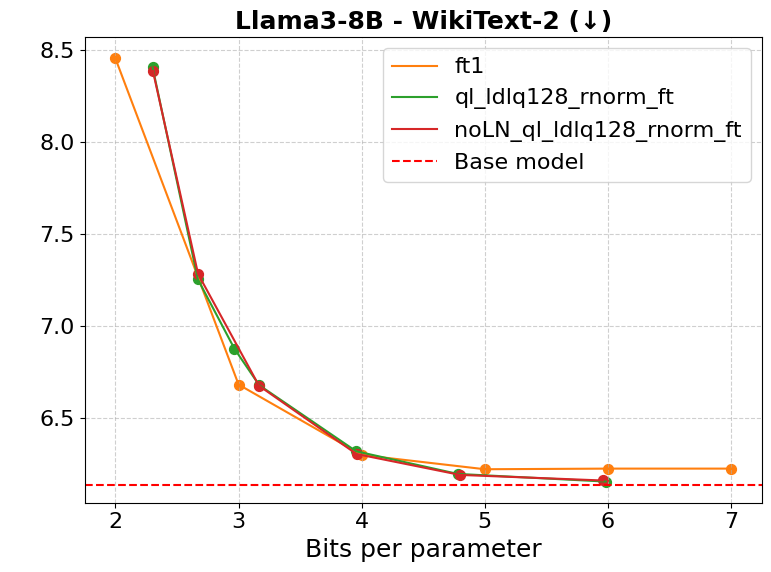

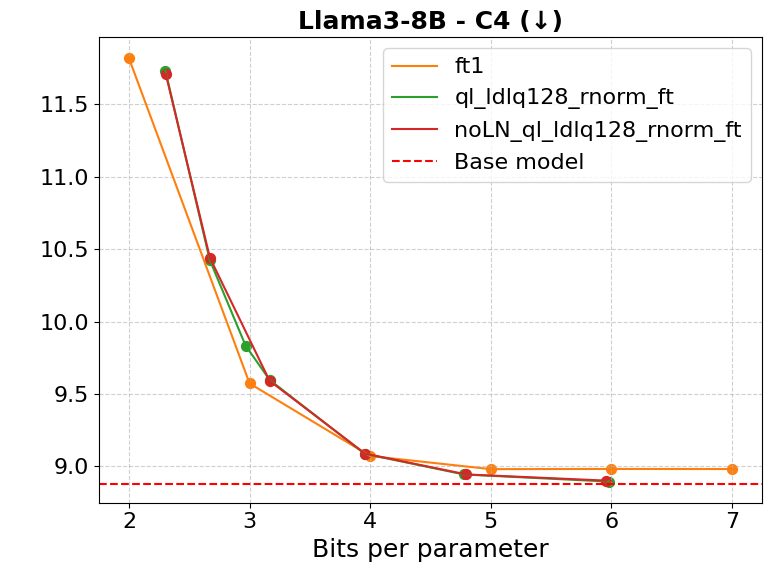

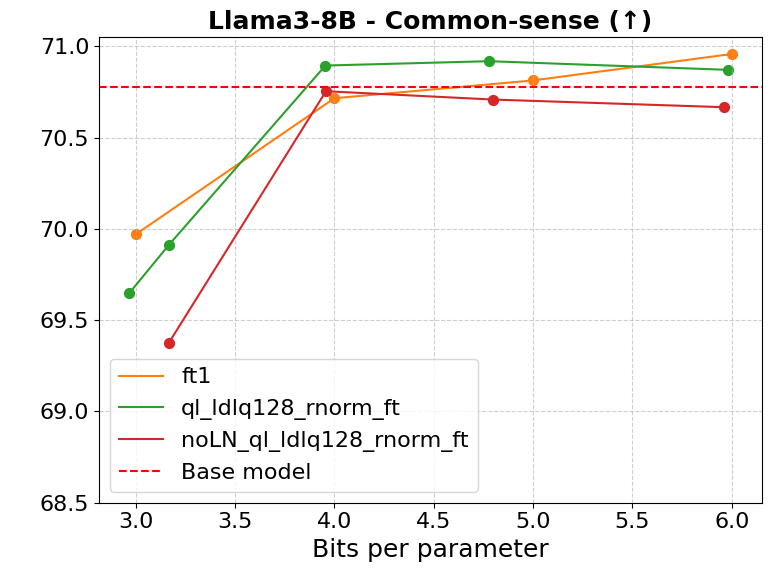

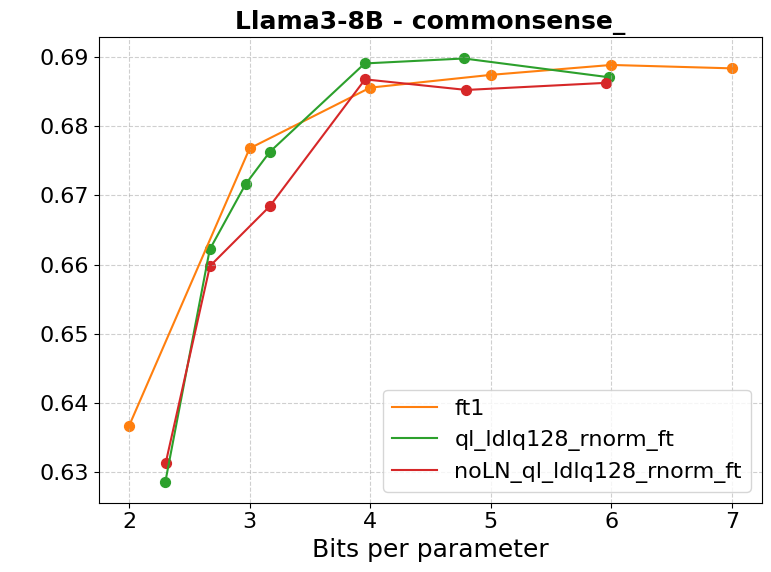

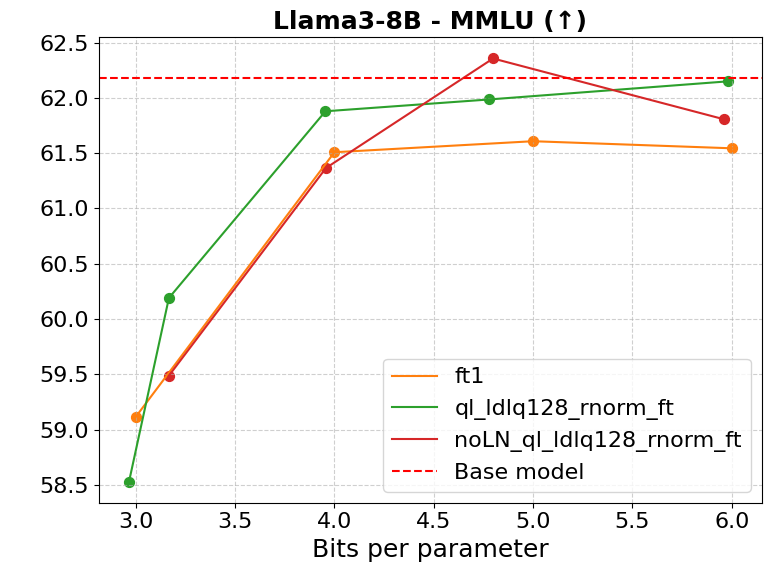

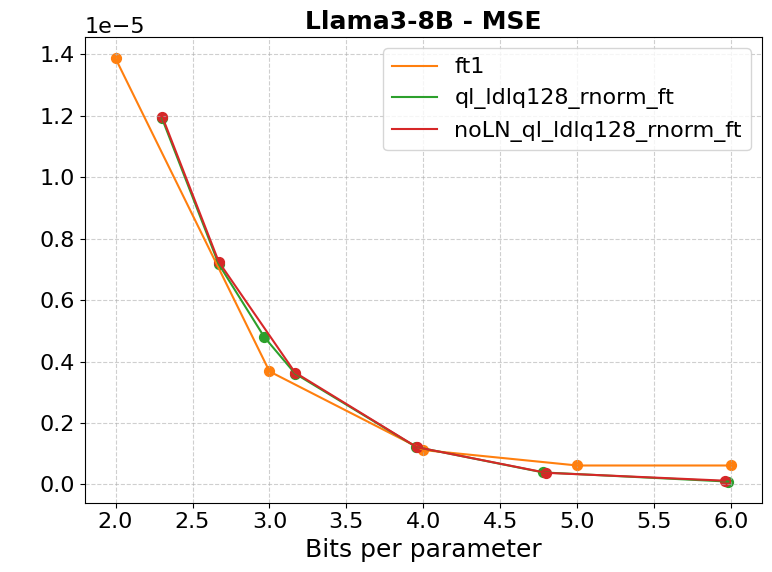

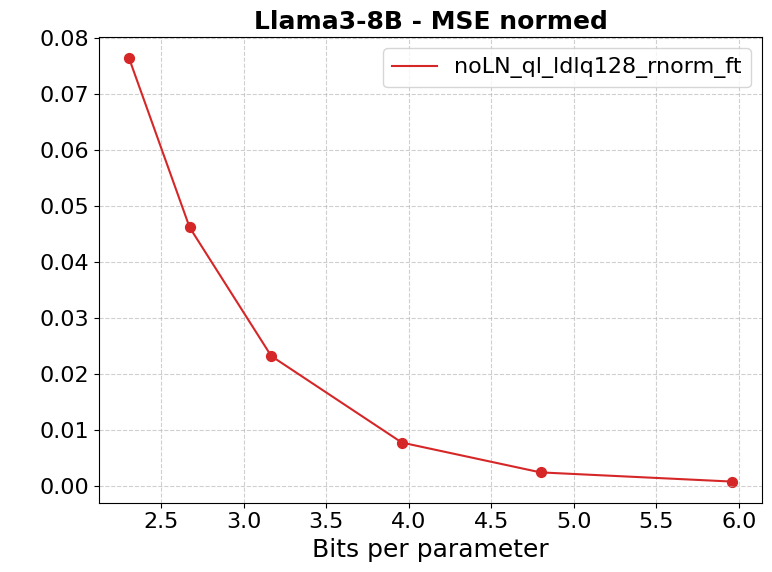

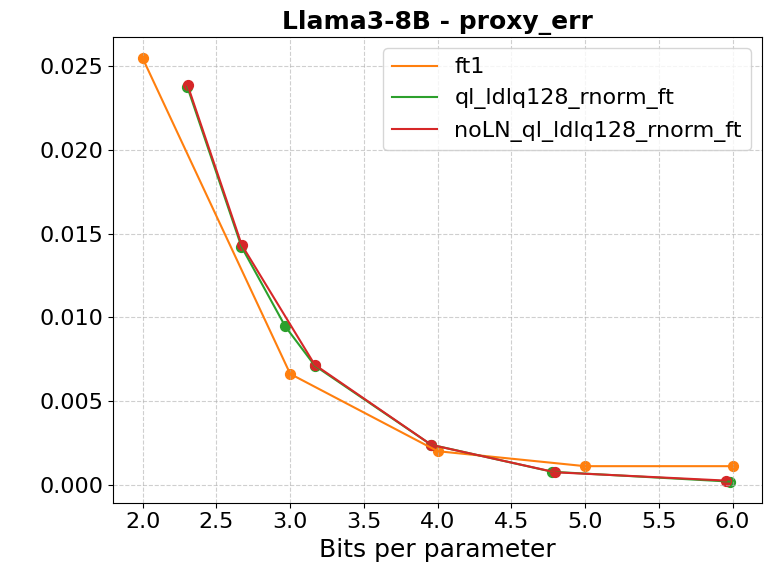

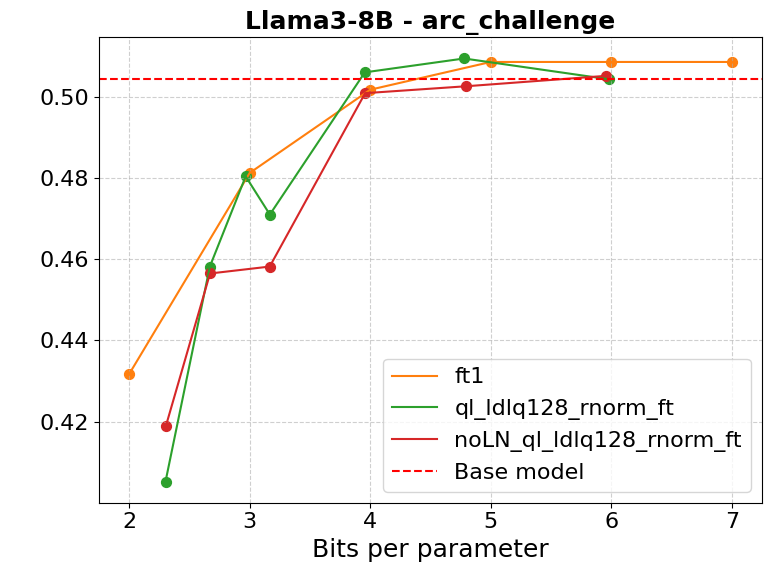

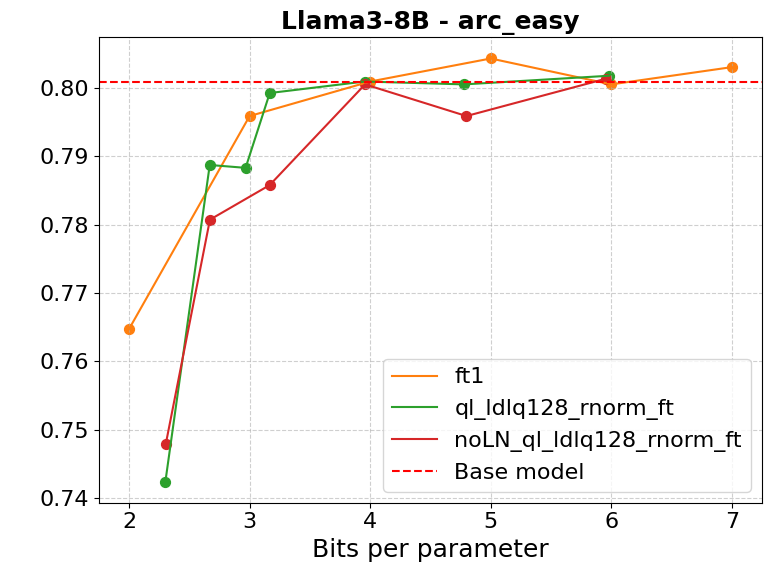

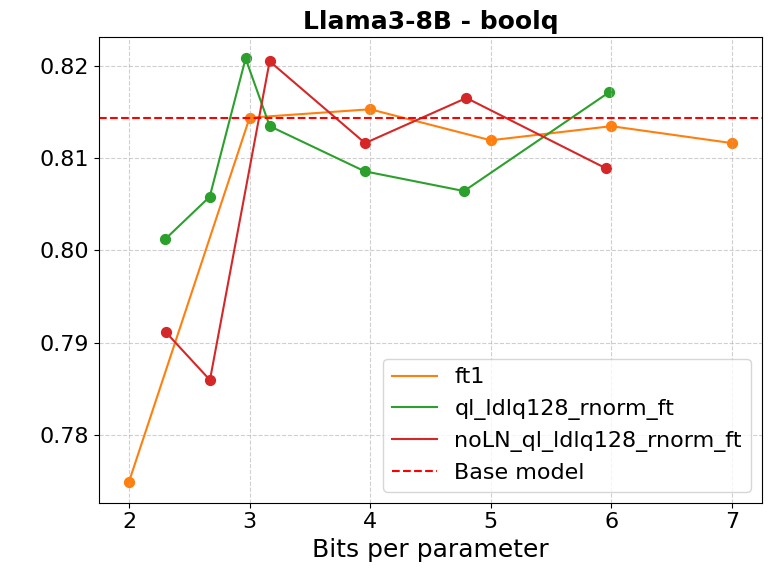

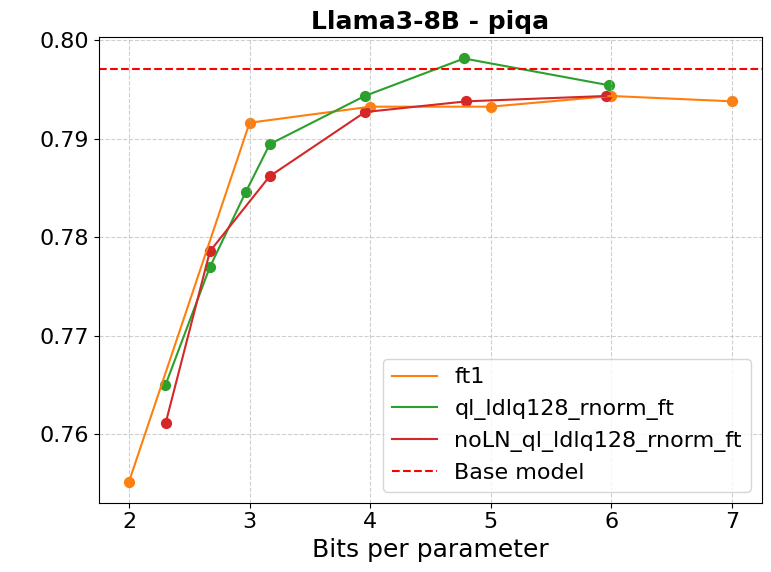

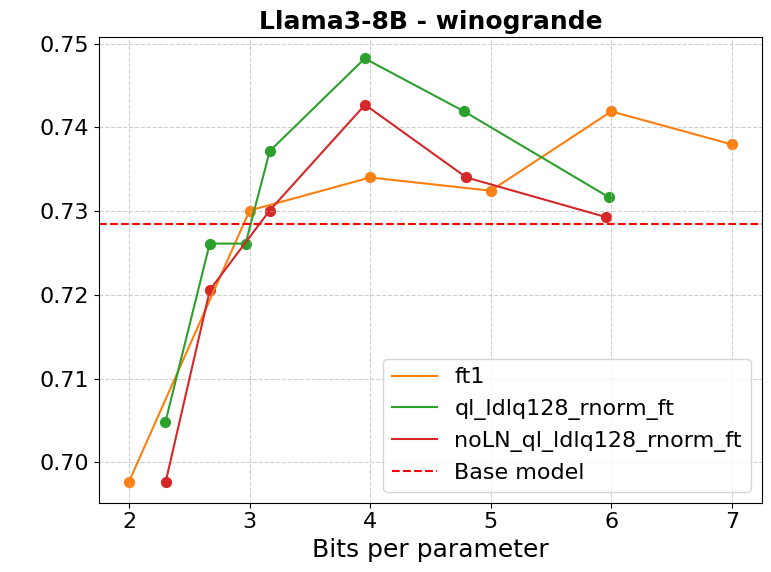

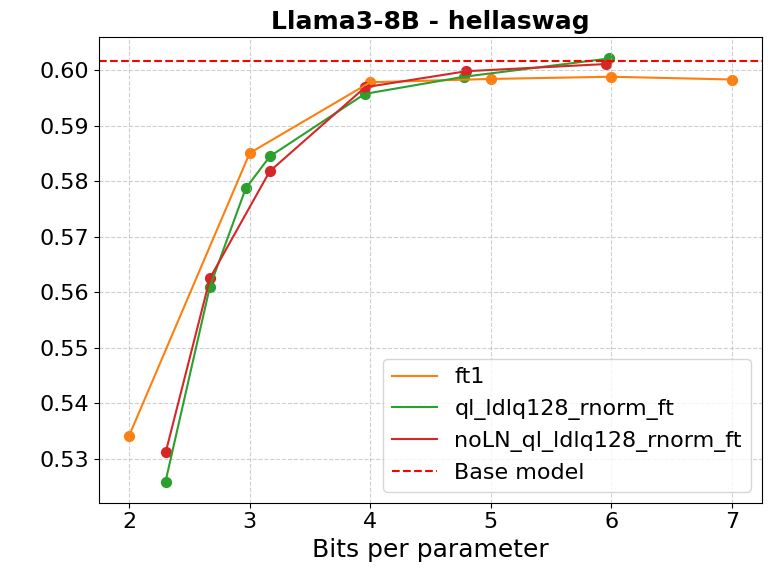

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib.cm as cm
import os

#################################################################
##                      PLOT CONFIGURATION                     ##
#################################################################
plot_name = [
    # 'GPTQ',
    # 'AWQ',
    # 'SpinQ',
    # 'QuIP#_no_e2e',
    # 'QTIP_no_e2e',
    # 'ft1',
    # 'QTIP_no_ft',
    # 'LLM-QAT',
    # 'BitDistiller',
    # 'ReALLM',
    # 'VQ_rnorm',
    # 'NWC_ql_ldlq128_rnorm_ft',
    # 'NWC_ql_ldlq128_rnorm_ft_seed2',
    # 'NWC_ql_ldlq128_rnorm_ft_seed3',
    # 'ReALLM_noft',
    # 'SeedLM',
### ablations
    # 'ql_ldlq128_rnorm_ft',
    # 'ql_ldlq128_rnorm_ft_seed2',
    # 'ql_ldlq128_rnorm_ft_seed3',
    # 'noLN_ql_ldlq128_rnorm_ft',
    'ql_rnorm',
]
plot_labels = [
    # 'GPTQ',
    # 'AWQ',
    # 'SpinQ',
    # r'QuIP#$^⁎$',
    # 'QuIP',
    r'QTIP$^⁎$',
    # 'QTIP',
    # 'ReALLM',
    # 'SeedLM',
    # 'NWC',
    # 'NWC (ch_sz 4)',
    # 'NWC (no LN)',
    # 'NWC (2)',
    # 'NWC (4)',
    # r'NWC$^†$',
    # r'NWC$^†$ (ch_sz 16)',
    # r'NWC$^†$ (ch_sz 4)',
    # r'NWC$^†$ (4)',
    # 'QL',
    # 'QL + perlayer tuning 10ep',
    # 'QL + perlayer tuning 50ep',
    # 'Importance aware neural compresser',
    # '+ Intra-layer error feedback',
    # '+ Inter-layer recovery fine-tuning',
    # 'Neural Compressor',
    # '+ Importance awareness'
    # 'NWC',
    # 'ablation_MSEv1',
    # 'ablation_MSEv2',
    # 'ablation_MSEv3',
    # 'LLM-QAT',
    # 'BitDistiller',
    # 'ReALLM (no finetuning)',
    # 'NWC (data-free)',
    # 'Global',
    # 'Tensor-wise',
    # 'Channel-wise',
    # 'nonlinear SQ',
    # 'Vector Quantizer',
    # 'Entropy coding',
]

plot_keys = [
    ('ppl_wikitext2', 'WikiText-2 (↓)'),
    ('ppl_c4', 'C4 (↓)'),
    # ('zeroshot','Zero-shot '), 
    ('commonsense', 'Common-sense (↑)'),
    ('commonsense_', 'commonsense_'),
    ('mmlu', 'MMLU (↑)'),
    ('mse', 'MSE'),
    ('mse_normed', 'MSE normed'),
    ('proxy_err', 'proxy_err'),
    # ('qat', 'Zero-shot')
    ('arc_challenge', 'arc_challenge'),
    ('arc_easy', 'arc_easy'),
    ('boolq', 'boolq'),
    ('piqa', 'piqa'),
    ('winogrande', 'winogrande'),
    ('hellaswag', 'hellaswag'),
    ]
models = [
    'Llama3-8B',
    # 'Llama2-7B',
    # 'Llama2-13B',
    # 'Mixtral',
    # 'Qwen3Moe'
]

SPLINE_ORDER = 1
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18
# plt.rcParams['axes.labelsize'] = 23
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
# plt.rcParams['legend.fontsize'] = 20
plt.rcParams['figure.titlesize'] = 20

# Create a directory to save plots if it doesn't exist
output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)
#################################################################
##                      HELPER FUNCTION                        ##
#################################################################
def replace_none_with_nan(data):
    """None 값을 np.nan으로 변환하여 계산에 용이하게 합니다."""
    return np.array([np.nan if val is None else val for val in data])
#################################################################
##                         MAIN SCRIPT                         ##
#################################################################
if not plot_labels or len(plot_labels) != len(plot_name):
    plot_labels = plot_name

cmap = cm.get_cmap('tab10')
colors = {}
idx = 1
for name in plot_labels:
    if 'Ours' in name:
    # if 'NWC' in name:
        colors[name] = cmap(0)
    else:
        colors[name] = cmap(idx)
        idx += 1

for m_name in models:
    if m_name not in ppl_plots:
        print(f"Skipping model {m_name}: No data found.")
        continue
    
    plots_data = ppl_plots[m_name]
    for plot_key, key_label in plot_keys:
        
        # Create a single plot
        fig, ax = plt.subplots(figsize=(8, 6))

        for k, label in zip(plot_name, plot_labels):
            try:
                v = plots_data[k]
                
                bpp = replace_none_with_nan(v['bpp'])
                metric = replace_none_with_nan(v[plot_key])

                mask = np.isfinite(bpp) & np.isfinite(metric) & (metric < 1000)
                if plot_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                    metric = metric * 100
                
                sort_indices = np.argsort(bpp[mask])
                bpp_sorted = bpp[mask][sort_indices]
                metric_sorted = metric[mask][sort_indices]
                
                # if len(bpp_sorted) > SPLINE_ORDER:
                if False:
                    x_smooth = np.linspace(bpp_sorted.min(), bpp_sorted.max(), 300)
                    spline = make_interp_spline(bpp_sorted, metric_sorted, k=SPLINE_ORDER)
                    y_smooth = spline(x_smooth)
                else:
                    x_smooth, y_smooth = bpp_sorted, metric_sorted # Not enough points for spline
                
                marker = 'o'
                # marker = 's' if 'NWC' in label else 'o'
                marker_size = 100 if marker == 's' else 50
                lw = 2.5 if marker == 's' else 1.5
                # linestyle = '-.' if 'gaussian' in k else '-'
                linestyle = '-.' if 'qtip' in k.lower() else '-'
                color = colors[label]
                # linestyle = '-.'
                
                # zoom_range = (2.7, 8)
                zoom_range = (0, 8)
                if 'ppl' in plot_key:
                    zoom_range = (1.7, 8) ## full range
                    # zoom_range = (3.5, 6.01) ## main
                    # zoom_range = (2.7, 6.05) ## main v2
                    # zoom_range = (1.7, 6) ## full range
                    # zoom_range = (1.8, 6) ## e2e
                    # zoom_range = (1.8, 4.5) ## ReALLM, LLMQAT
                    # zoom_range = (1.8, 4.1) ## Normalization ablation
                    # zoom_range = (2.5, 6.02) ## VQ
                    # zoom_range = (2.0, 5.0) ## data free 
                    # zoom_range = (2.5, 8) ## data free 
                    # zoom_range = (2, 6) ## ablation 
                    # zoom_range = (2, 4.0) ## ablation 
                if plot_key in ['commonsense', 'zeroshot', 'mmlu']: 
                    # zoom_range = (2.7, 6.03) # main
                    zoom_range = (2.7, 6.5)
                    # zoom_range = (1.7, 6)
                if plot_key in ['qat']: 
                    zoom_range = (2.1, 4.1)
                
                zoom_data_mask = (bpp_sorted >= zoom_range[0]) & (bpp_sorted <= zoom_range[1])
                zoom_smooth_mask = (x_smooth >= zoom_range[0]) & (x_smooth <= zoom_range[1])
                
                # Plotting on the single axis
                ax.plot(x_smooth[zoom_smooth_mask], y_smooth[zoom_smooth_mask], linestyle=linestyle, color=color, label=label, alpha=1, lw=lw)
                ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask], color=color, marker=marker, s=marker_size, alpha=1)
                
                if 'c4' in plot_key:
                    if '8B' in m_name:
                        # ax.set_ylim(8.87, 9.4) # main
                        # ax.set_ylim(8.87, 20)
                        pass
                    if '7B' in m_name:
                        # ax.set_ylim(6.97, 7.3) # main
                        ax.set_ylim(6.97, 7.6) # main v2
                        # ax.set_ylim(6.97, 10) # ReALLM
                        pass
                    if '13B' in m_name:
                        # ax.set_ylim(6.46, 6.7) # main
                        ax.set_ylim(6.46, 6.92) # main v2
                        pass
                if 'wiki' in plot_key:
                    if '8B' in m_name:
                        # ax.set_ylim(6,15)
                        # ax.set_ylim(6.1, 6.9) # main
                        # ax.set_ylim(6,11) # data free
                        pass
                    if '7B' in m_name:
                        ax.set_ylim(5.4, 7.8) # data free
                        # ax.set_ylim(5.4, 7.5) # ReALLM
                        pass
                    if '13B' in m_name:
                        ax.set_ylim(4.8, 5.85) # data free
                        pass
                if plot_key in ['commonsense']:
                    if '8B' in m_name:
                        ax.set_ylim(68.5,71.05)
                        pass
                    if '7B' in m_name:
                        ax.set_ylim(65, 67.33)
                        pass
                    if '13B' in m_name:
                        ax.set_ylim(60, 70)
                        pass
                if plot_key in ['zeroshot']:
                    if '8B' in m_name:
                        # ax.set_ylim(68.5,71)
                        pass
                    if '7B' in m_name:
                        ax.set_ylim(65, 70)
                        pass
                    if '13B' in m_name:
                        ax.set_ylim(60, 70)
                        pass
                if plot_key in ['mmlu']:
                    if '8B' in m_name:
                        # ax.set_ylim(57, 62.3)
                        pass
                        
            except (KeyError, ValueError) as e:
                print(f"Warning: Could not plot '{k}' for '{m_name}' due to error: {e}. Skipping.")
            except Exception as e:
                print(f"An unexpected error occurred while plotting '{k}' for '{m_name}': {e}")
        
        # Define y-axis label
        if 'ppl' in plot_key:
            y_label = 'Perplexity (↓)'
        elif plot_key in ['commonsense', 'zeroshot', 'qat']: 
            y_label = 'Avg. accuracy (↑)'
        elif plot_key in ['mmlu']: 
            y_label = 'Accuracy (%)'
        else:
            y_label = key_label

        # Apply final plot settings to the single axis
        try:
            fp16_val = plots_data['FP16'][plot_key]
            if plot_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                fp16_val = fp16_val * 100
            # ax.axhline(y=fp16_val, color='purple', linestyle='--', label='Baseline')
            ax.axhline(y=fp16_val, color='r', linestyle='--', label='Base model')
        except KeyError:
            pass
            
        ax.set_xlabel('Bits per parameter')
        # ax.set_xlabel('Avg. Bits')
        # ax.set_ylabel(y_label)
        ax.set_ylabel(" ")
        ax.grid(True, which='both', linestyle='--', alpha=0.6)
        # if plot_key not in ['ppl_wikitext2', 'ppl_c4']:
        ax.legend()
        ax.set_title(f'{m_name} - {key_label}', weight='bold')
        if 'mse' in plot_key or 'proxy_err' in plot_key:
            # ax.set_yscale('log')
            pass
        plt.tight_layout()
        
        # Save the figure to a file
        filename = os.path.join(output_dir, f'{m_name}_{plot_key}.pdf')
        plt.savefig(filename, dpi=300)
        print(f"Plot saved to {filename}")
        
        # Close the plot to free up memory
        # plt.close(fig)

# Llama3 8B

In [ ]:
import pandas as pd

def dict_to_dataframe(ppl_plots):
    rows = []
    
    for model_name, experiments in ppl_plots.items():
        for exp_name, metrics in experiments.items():
            
            # 1. 반복 횟수(데이터 포인트 수) 결정
            if 'bpp' in metrics:
                n_points = len(metrics['bpp'])
            elif 'lambda' in metrics:
                n_points = len(metrics['lambda'])
            elif exp_name == 'FP16':
                n_points = 1 
            else:
                print('Missing metrics for logic: ', model_name, exp_name)
                # [수정] n_points가 정의되지 않은 상태로 아래 루프에 진입하지 않도록 건너뜁니다.
                continue 

            for i in range(n_points):
                row = {
                    'Model': model_name,
                    'Experiment': exp_name
                }
                
                for metric_name, values in metrics.items():
                    # 리스트인 경우 해당 인덱스 값 추출
                    if isinstance(values, list):
                        if i < len(values):
                            row[metric_name] = values[i]
                    # 단일 값(int, float, str)인 경우 그대로 사용
                    elif isinstance(values, (int, float, str)):
                        row[metric_name] = values
                        
                rows.append(row)
    
    return pd.DataFrame(rows)


def dataframe_to_dict(df):
    restored_dict = {}
    
    # 1. Model과 Experiment를 기준으로 그룹핑
    # sort=False: 데이터프레임에 정렬된 순서(bpp 순)를 그대로 유지하기 위해 중요함
    grouped = df.groupby(['Model', 'Experiment'], sort=False)
    
    for (model, exp), group in grouped:
        if model not in restored_dict:
            restored_dict[model] = {}
        
        restored_dict[model][exp] = {}
        
        # 2. 메트릭 컬럼들만 순회 (Model, Experiment 컬럼 제외)
        metric_cols = [c for c in group.columns if c not in ['Model', 'Experiment']]
        
        for col in metric_cols:
            # 3. 중요: 해당 실험에서 데이터가 하나라도 있는 컬럼만 저장
            # (다른 실험에는 있는데 이 실험엔 없어서 전원 NaN인 컬럼은 딕셔너리 키에서 제외)
            if group[col].notna().any():
                # 리스트로 변환 (NaN도 포함되어 위치 정보 유지됨)
                restored_dict[model][exp][col] = group[col].tolist()
                
    return restored_dict

df_master = dict_to_dataframe(ppl_plots)
df_master.to_csv("./experiment_results_summary.csv", index=False)

restored_ppl_plots = dataframe_to_dict(df_master)

In [45]:
restored_ppl_plots['Llama3-8B']['FP16']

{'ppl_wikitext2': [6.135671615600586],
 'ppl_c4': [8.88062572479248],
 'hellaswag': [0.6016729735112527],
 'mathqa': [0.4067001675041876],
 'openbookqa': [0.348],
 'pubmedqa': [0.748],
 'sciq': [0.964],
 'zeroshot': [0.7290239504254532],
 'commonsense': [0.7077987876064199],
 'average9': [0.6248078241902062],
 'mmlu': [0.6217775245691497]}

In [46]:
import numpy as np

def compare_dicts_ignore_nan_type(d1, d2):
    """
    두 딕셔너리(d1, d2)를 재귀적으로 비교합니다.
    - NaN끼리는 같다고 간주합니다.
    - 5와 5.0은 같다고 간주합니다.
    - 리스트 내부 순서도 일치해야 합니다.
    """
    
    # 1. 키(Key) 비교
    if d1.keys() != d2.keys():
        print(f"❌ Key Mismatch: {d1.keys()} vs {d2.keys()}")
        return False

    for k in d1:
        val1 = d1[k]
        val2 = d2[k]

        # 2. 내부가 또 딕셔너리인 경우 (재귀 호출)
        if isinstance(val1, dict) and isinstance(val2, dict):
            if not compare_dicts_ignore_nan_type(val1, val2):
                print(f"❌ Mismatch inside key: '{k}'")
                return False
        
        # 3. 리스트인 경우 (값 비교)
        elif isinstance(val1, list) and isinstance(val2, list):
            if len(val1) != len(val2):
                print(f"❌ Length mismatch at '{k}': {len(val1)} vs {len(val2)}")
                return False
            
            for i, (v1, v2) in enumerate(zip(val1, val2)):
                # 둘 다 NaN이면 통과
                if pd.isna(v1) and pd.isna(v2):
                    continue
                
                # 숫자 비교 (float tolerance 적용)
                try:
                    if not np.isclose(v1, v2, equal_nan=True):
                        print(f"❌ Value mismatch at '{k}' index {i}: {v1} != {v2}")
                        return False
                except:
                    # 숫자가 아니면 일반 비교
                    if v1 != v2:
                        print(f"❌ Value mismatch at '{k}' index {i}: {v1} != {v2}")
                        return False
        
        # 4. 그 외 단순 값 비교
        else:
            if pd.isna(val1) and pd.isna(val2):
                continue
            if val1 != val2:
                print(f"❌ Type or Value mismatch at '{k}': {val1} vs {val2}")
                return False

    return True

# --- 검증 실행 ---
is_identical = compare_dicts_ignore_nan_type(ppl_plots, restored_ppl_plots)

if is_identical:
    print("✅ 검증 성공! 두 딕셔너리의 데이터가 논리적으로 동일합니다.")
else:
    print("❌ 검증 실패! 위 로그를 확인하세요.")

❌ Type or Value mismatch at 'ppl_wikitext2': 7.813621997833252 vs [7.813621997833252]
❌ Mismatch inside key: 'FP16'
❌ Mismatch inside key: 'Llama3.2-3B'
❌ 검증 실패! 위 로그를 확인하세요.


In [47]:
import os
import shutil
import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo

def _timestamp_kr():
    return datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M%S")

def save_update_csv_in_timefolder(base_path, df, ts=None, **kwargs):
    """
    기존 CSV 파일이 있으면 {dirname}/save/{ts}/{basename}.csv 에 백업하고,
    새로운 DataFrame을 base_path에 저장합니다.
    
    Args:
        base_path (str): 저장할 메인 파일 경로 (예: ./results/summary.csv)
        df (pd.DataFrame): 저장할 데이터프레임
        ts (str): 타임스탬프 (None이면 자동 생성)
        **kwargs: df.to_csv()에 전달할 추가 인자 (예: sep='\t')
    
    Returns:
        (archived_path, base_path): 백업된 경로와 저장된 경로
    """
    
    # 1. 타임스탬프 및 경로 설정
    if ts is None:
        ts = _timestamp_kr()
        
    parent = os.path.dirname(base_path) or "."
    fname = os.path.basename(base_path)
    archived_path = None

    # 2. 아카이브: 기존 파일이 존재하면 save 폴더로 복사(백업)
    if os.path.exists(base_path):
        out_dir = os.path.join(parent, 'save', ts)
        os.makedirs(out_dir, exist_ok=True)
        archived_path = os.path.join(out_dir, fname)
        
        # 단순 파일 복사 (가장 안전하고 빠름)
        shutil.copy2(base_path, archived_path)

    # 3. 저장: 임시 파일에 쓰고 원본 교체 (Atomic Write)
    # 저장 경로 생성
    os.makedirs(parent, exist_ok=True)
    
    tmp_path = base_path + ".tmp"
    
    # 기본값 index=False 설정 (kwargs로 덮어쓰기 가능)
    save_kwargs = {'index': False} 
    save_kwargs.update(kwargs)
    
    df.to_csv(tmp_path, **save_kwargs)
    
    # 임시 파일을 원본 파일명으로 교체
    os.replace(tmp_path, base_path)

    return archived_path, base_path


csv_path = './exp_results/summary.csv'
archived, saved = save_update_csv_in_timefolder(csv_path, df_master)

print(f"Archived: {archived}")
print(f"Saved New CSV: {saved}")

Archived: ./exp_results/save/20260107_225137/summary.csv
Saved New CSV: ./exp_results/summary.csv


# Llama2 70B

In [48]:

# 'bpp' :  [2.6833833194369743] ,
# 'ppl_wikitext2' :  [3.462212085723877] ,
# 'ppl_c4' :  [5.259450435638428] ,
# 'ppl_ptb' :  [15.485223770141602] ,
# 'zeroshot' :  [0.7161215247656517] ,

# Save